# Crypto Market Data Collection
## CoinGecko API

pip install requests pandas

In [67]:
import requests
import pandas as pd
import numpy as np

## 1.1 CoinGecko API Connection

The CoinGecko API is used as the primary data source for this project.

The market endpoint provides current cryptocurrency market information such as:

- Market capitalization rank
- Current price
- Market capitalization
- Trading volume
- 24-hour price change

In this initial step, the top 10 cryptocurrencies by market capitalization are requested to verify the API connection and inspect the available data structure.

In [3]:
url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 10,
    "page": 1,
    "sparkline": False
}

response = requests.get(url, params=params)

response.status_code

200

## 1.2 Initial Market Data Inspection

After receiving a successful API response, the JSON data is converted into a Pandas DataFrame.

The purpose of this step is to inspect the structure of the market data and identify the columns that will be relevant for the financial analytics pipeline.

In [4]:
data = response.json()

data[:2]

[{'id': 'bitcoin',
  'symbol': 'btc',
  'name': 'Bitcoin',
  'image': 'https://coin-images.coingecko.com/coins/images/1/large/bitcoin.png?1696501400',
  'current_price': 81321,
  'market_cap': 1633465843136,
  'market_cap_rank': 1,
  'fully_diluted_valuation': 1633465843136,
  'total_volume': 39483093491,
  'high_24h': 81675,
  'low_24h': 77934,
  'price_change_24h': 3323.45,
  'price_change_percentage_24h': 4.27001,
  'market_cap_change_24h': 66793902808,
  'market_cap_change_percentage_24h': 4.26343,
  'circulating_supply': 20086521.0,
  'total_supply': 20086521.0,
  'max_supply': 21000000.0,
  'ath': 126080,
  'ath_change_percentage': -35.50003,
  'ath_date': '2025-10-06T10:57:42.000Z',
  'atl': 67.81,
  'atl_change_percentage': 119827.28298,
  'atl_date': '2013-07-05T16:00:00.000Z',
  'roi': None,
  'last_updated': '2026-09-19T11:23:20.000Z'},
 {'id': 'ethereum',
  'symbol': 'eth',
  'name': 'Ethereum',
  'image': 'https://coin-images.coingecko.com/coins/images/279/large/ethereum.p

In [5]:
df = pd.DataFrame(data)
df.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,81321.000000,1633465843136,1,1633465843136,39483093491,81675.000000,...,2.008652e+07,2.100000e+07,126080.00,-35.50003,2025-10-06T10:57:42.000Z,67.810000,1.198273e+05,2013-07-05T16:00:00.000Z,None,2026-09-19T11:23:20.000Z
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2640.220000,322270496175,2,322270496175,21355583349,2655.710000,...,1.220618e+08,NaN,4946.05,-46.61951,2025-08-24T11:21:03.000Z,0.432979,6.096815e+05,2015-10-19T16:00:00.000Z,"{'times': 42.408078027830896, 'currency': 'btc...",2026-09-19T11:23:20.000Z
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999647,183319831377,3,188784845016,74775852895,0.999786,...,1.888516e+11,NaN,1.32,-24.44637,2018-07-23T16:00:00.000Z,0.572521,7.460435e+01,2015-03-01T16:00:00.000Z,None,2026-09-19T11:23:20.000Z
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,766.070000,102010064236,4,102010054377,1258349490,769.320000,...,1.331603e+08,2.000000e+08,1369.99,-44.08219,2025-10-13T00:41:24.000Z,0.039818,1.923842e+06,2017-10-18T16:00:00.000Z,None,2026-09-19T11:23:20.000Z
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.430000,89806624548,5,142803499874,4267585365,1.440000,...,9.998562e+10,1.000000e+11,3.65,-60.83126,2025-07-17T19:40:53.000Z,0.002686,5.306941e+04,2014-05-21T16:00:00.000Z,None,2026-09-19T11:23:20.000Z


In [6]:
df.shape

(10, 26)

In [7]:
df.columns.tolist()

['id',
 'symbol',
 'name',
 'image',
 'current_price',
 'market_cap',
 'market_cap_rank',
 'fully_diluted_valuation',
 'total_volume',
 'high_24h',
 'low_24h',
 'price_change_24h',
 'price_change_percentage_24h',
 'market_cap_change_24h',
 'market_cap_change_percentage_24h',
 'circulating_supply',
 'total_supply',
 'max_supply',
 'ath',
 'ath_change_percentage',
 'ath_date',
 'atl',
 'atl_change_percentage',
 'atl_date',
 'roi',
 'last_updated']

In [8]:
df[
    [
        "market_cap_rank",
        "name",
        "symbol",
        "current_price",
        "market_cap",
        "total_volume",
        "price_change_percentage_24h"
    ]
]

,market_cap_rank,name,symbol,current_price,market_cap,total_volume,price_change_percentage_24h
0,1,Bitcoin,btc,81321.000000,1633465843136,39483093491,4.27001
1,2,Ethereum,eth,2640.220000,322270496175,21355583349,5.57394
2,3,Tether,usdt,0.999647,183319831377,74775852895,0.04829
3,4,BNB,bnb,766.070000,102010064236,1258349490,2.18888
4,5,XRP,xrp,1.430000,89806624548,4267585365,8.34620
5,6,USDC,usdc,0.999758,74256403733,20120425925,0.02494
6,7,Solana,sol,111.980000,65767938220,5417032623,6.23159
7,8,TRON,trx,0.337763,32072658481,436879359,0.18521
8,9,Zcash,zec,1540.560000,26097507638,1568544492,5.36088
9,10,Figure Heloc,figr_heloc,1.030000,23395526102,52702286,NaN


In [10]:
import requests

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params = {
    "vs_currency": "usd",
    "days": "30"
}

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(
    url,
    params=params,
    headers=headers,
    timeout=30
)

print(response.status_code)

200


## 1.4 Historical Data Structure Inspection

The structure of the historical API response is inspected before transforming the data.

The response contains three main time-series datasets:

- `prices`
- `market_caps`
- `total_volumes`

Each dataset contains timestamp-value pairs that can be combined into a unified market dataset.

In [11]:
btc_history = response.json()

print(btc_history.keys())

dict_keys(['prices', 'market_caps', 'total_volumes'])


In [13]:
len(btc_history["prices"])

721

In [14]:
len(btc_history["market_caps"])

721

In [15]:
len(btc_history["total_volumes"])

721

In [16]:
btc_history["prices"][0]

[1787227200000, 71877.57267444955]

In [17]:
btc_history["market_caps"][0]

[1787227200000, 1442691993731.5222]

In [18]:
btc_history["total_volumes"][0]

[1787227200000, 65448950397.47016]

## 1.5 Historical Price DataFrame

The historical Bitcoin price series is extracted from the API response and converted into a Pandas DataFrame.

The original timestamps are provided in Unix milliseconds, so they are converted into datetime values to make the data suitable for time-series analysis.

This DataFrame is used to inspect the historical observation frequency and date range before building the final market dataset.

In [19]:
prices_df = pd.DataFrame(
    btc_history["prices"],
    columns=["timestamp", "price"]
)

prices_df.head()

,timestamp,price
0,1787227200000,71877.572674
1,1787230800000,71889.217267
2,1787234400000,71618.682890
3,1787238000000,71748.964172
4,1787241600000,72425.672274


In [20]:
prices_df.shape

(721, 2)

In [21]:
prices_df["date"] = pd.to_datetime(
    prices_df["timestamp"],
    unit="ms"
)

In [22]:
prices_df.head()

,timestamp,price,date
0,1787227200000,71877.572674,2026-08-20 12:00:00
1,1787230800000,71889.217267,2026-08-20 13:00:00
2,1787234400000,71618.682890,2026-08-20 14:00:00
3,1787238000000,71748.964172,2026-08-20 15:00:00
4,1787241600000,72425.672274,2026-08-20 16:00:00


In [23]:
print(len(btc_history["prices"]))
print(len(btc_history["market_caps"]))
print(len(btc_history["total_volumes"]))

721
721
721


In [24]:
prices_df.tail()

,timestamp,price,date
716,1789804800000,81098.542098,2026-09-19 08:00:00
717,1789808400000,81285.512688,2026-09-19 09:00:00
718,1789812000000,81301.075559,2026-09-19 10:00:00
719,1789815600000,81203.087096,2026-09-19 11:00:00
720,1789817280000,81269.361468,2026-09-19 11:28:00


In [25]:
prices_df["date"].min(), prices_df["date"].max()

(Timestamp('2026-08-20 12:00:00'), Timestamp('2026-09-19 11:28:00'))

# 2. Historical Data Inspection

In this section, we inspect the structure, size, and time range of the historical Bitcoin market data retrieved from the CoinGecko API.

The main objectives are:

- Check the number of observations for each metric
- Verify that the historical series have consistent lengths
- Identify the available date range
- Understand the data granularity returned by the API

### 2.1 Number of Historical Observations

The CoinGecko historical endpoint returns three main market data series:

- Price
- Market Capitalization
- Total Trading Volume

We first verify the number of observations available for each series.

In [26]:
print("Prices:", len(btc_history["prices"]))
print("Market Caps:", len(btc_history["market_caps"]))
print("Total Volumes:", len(btc_history["total_volumes"]))

Prices: 721
Market Caps: 721
Total Volumes: 721


### 2.2 Historical Date Range

The timestamp values returned by the API are converted into datetime values so that we can identify the exact historical period covered by the dataset.

In [27]:
prices_df["date"].min(), prices_df["date"].max()

(Timestamp('2026-08-20 12:00:00'), Timestamp('2026-09-19 11:28:00'))

### 2.3 Last Observations

We inspect the final observations to verify that the historical time series is complete and ordered chronologically.

In [28]:
prices_df.tail()

,timestamp,price,date
716,1789804800000,81098.542098,2026-09-19 08:00:00
717,1789808400000,81285.512688,2026-09-19 09:00:00
718,1789812000000,81301.075559,2026-09-19 10:00:00
719,1789815600000,81203.087096,2026-09-19 11:00:00
720,1789817280000,81269.361468,2026-09-19 11:28:00


### 2.4 Data Granularity

The time difference between consecutive observations is examined to determine the granularity of the historical data returned by the API.

In [29]:
prices_df["date"].diff().value_counts()

date
0 days 01:00:00    719
0 days 00:28:00      1
Name: count, dtype: int64

### 2.5 Build Historical Market DataFrame

The historical market data returned by the CoinGecko API contains three separate time series:

- Price
- Market Capitalization
- Total Trading Volume

In this step, we combine these series into a single DataFrame using the common timestamp as the key.

This structure will make the data easier to clean, transform, analyze, and load into the database in later stages.

In [30]:
market_df = pd.DataFrame({
    "timestamp": [x[0] for x in btc_history["prices"]],
    "price": [x[1] for x in btc_history["prices"]],
    "market_cap": [x[1] for x in btc_history["market_caps"]],
    "total_volume": [x[1] for x in btc_history["total_volumes"]]
})

market_df["date"] = pd.to_datetime(
    market_df["timestamp"],
    unit="ms"
)

market_df.head()

,timestamp,price,market_cap,total_volume,date
0,1787227200000,71877.572674,1.442692e+12,6.544895e+10,2026-08-20 12:00:00
1,1787230800000,71889.217267,1.442926e+12,6.616856e+10,2026-08-20 13:00:00
2,1787234400000,71618.682890,1.437496e+12,6.689697e+10,2026-08-20 14:00:00
3,1787238000000,71748.964172,1.440111e+12,6.485029e+10,2026-08-20 15:00:00
4,1787241600000,72425.672274,1.453693e+12,5.926805e+10,2026-08-20 16:00:00


In [31]:
market_df.shape

(721, 5)

In [32]:
market_df.columns.tolist()

['timestamp', 'price', 'market_cap', 'total_volume', 'date']

### 2.6 Data Quality Check

Before transforming the historical market data, we perform basic data quality checks.

The main checks include:

- Missing values
- Duplicate records
- Chronological ordering
- Invalid negative values

These checks help ensure that the dataset is reliable before moving to the transformation and daily aggregation stages.

In [33]:
market_df.isnull().sum()

timestamp       0
price           0
market_cap      0
total_volume    0
date            0
dtype: int64

In [34]:
market_df.duplicated().sum()

np.int64(0)

In [35]:
market_df["date"].is_monotonic_increasing

True

In [36]:
print("Negative prices:", (market_df["price"] < 0).sum())
print("Negative market caps:", (market_df["market_cap"] < 0).sum())
print("Negative volumes:", (market_df["total_volume"] < 0).sum())

Negative prices: 0
Negative market caps: 0
Negative volumes: 0


### 2.7 Create Daily Market Data

The raw historical data is available at approximately hourly intervals.

For the analytical layer, we convert the hourly observations into daily market data.

The daily aggregation rules are:

- Daily Price: Last available price of the day (Daily Close)
- Daily Market Capitalization: Last available value of the day
- Daily Trading Volume: Sum of all observations during the day

The resulting dataset will have one row per day and will match the planned fact table grain:

**One Coin + One Date = One Fact Row**

In [37]:
market_df["date_only"] = market_df["date"].dt.date

market_df.head()

,timestamp,price,market_cap,total_volume,date,date_only
0,1787227200000,71877.572674,1.442692e+12,6.544895e+10,2026-08-20 12:00:00,2026-08-20
1,1787230800000,71889.217267,1.442926e+12,6.616856e+10,2026-08-20 13:00:00,2026-08-20
2,1787234400000,71618.682890,1.437496e+12,6.689697e+10,2026-08-20 14:00:00,2026-08-20
3,1787238000000,71748.964172,1.440111e+12,6.485029e+10,2026-08-20 15:00:00,2026-08-20
4,1787241600000,72425.672274,1.453693e+12,5.926805e+10,2026-08-20 16:00:00,2026-08-20


In [38]:
market_df["date_only"].nunique()

31

### 2.8 Daily Market Aggregation

The hourly market observations are aggregated into daily data.

For each calendar day:

- Price is represented by the last available price of the day.
- Market Capitalization is represented by the last available value of the day.
- Trading Volume is calculated as the sum of all available observations during the day.

This produces one market record per day.

In [39]:
daily_market_df = (
    market_df
    .groupby("date_only")
    .agg(
        price=("price", "last"),
        market_cap=("market_cap", "last"),
        total_volume=("total_volume", "sum")
    )
    .reset_index()
)

daily_market_df.head()

,date_only,price,market_cap,total_volume
0,2026-08-20,72660.836660,1.458413e+12,7.279433e+11
1,2026-08-21,78447.001746,1.574550e+12,1.557345e+12
2,2026-08-22,76998.181802,1.545470e+12,1.327823e+12
3,2026-08-23,77588.632845,1.557322e+12,7.184845e+11
4,2026-08-24,78727.756284,1.580435e+12,9.259620e+11


In [40]:
daily_market_df.shape

(31, 4)

In [41]:
daily_market_df.tail()

,date_only,price,market_cap,total_volume
26,2026-09-15,75645.584909,1.519336e+12,8.114489e+11
27,2026-09-16,75622.803855,1.518912e+12,8.770912e+11
28,2026-09-17,76353.277623,1.533613e+12,7.039233e+11
29,2026-09-18,81124.116682,1.629480e+12,7.805436e+11
30,2026-09-19,81269.361468,1.632419e+12,5.563087e+11


### 2.9 Calculate Daily Return

Daily Return measures the percentage change in the asset's closing price compared with the previous trading day.

The formula is:

Daily Return = (Today's Close / Previous Close) - 1

The first observation does not have a previous day in the dataset, so its Daily Return will be NaN.

In [42]:
daily_market_df["daily_return"] = (
    daily_market_df["price"] /
    daily_market_df["price"].shift(1)
) - 1

In [43]:
daily_market_df.head()

,date_only,price,market_cap,total_volume,daily_return
0,2026-08-20,72660.836660,1.458413e+12,7.279433e+11,NaN
1,2026-08-21,78447.001746,1.574550e+12,1.557345e+12,0.079633
2,2026-08-22,76998.181802,1.545470e+12,1.327823e+12,-0.018469
3,2026-08-23,77588.632845,1.557322e+12,7.184845e+11,0.007668
4,2026-08-24,78727.756284,1.580435e+12,9.259620e+11,0.014682


In [44]:
daily_market_df[
    ["date_only", "price", "daily_return"]
].head(10)

,date_only,price,daily_return
0,2026-08-20,72660.836660,NaN
1,2026-08-21,78447.001746,0.079633
2,2026-08-22,76998.181802,-0.018469
3,2026-08-23,77588.632845,0.007668
4,2026-08-24,78727.756284,0.014682
5,2026-08-25,78879.417778,0.001926
6,2026-08-26,78708.997983,-0.002161
7,2026-08-27,80297.004179,0.020176
8,2026-08-28,77738.782915,-0.031859
9,2026-08-29,78221.785638,0.006213


### 2.10 Finalize Daily Market Dataset

After aggregating the hourly observations and calculating Daily Return, we create the final daily market dataset.

The dataset contains:

- Date
- Closing Price
- Market Capitalization
- Total Trading Volume
- Daily Return

The first day's Daily Return remains NaN because there is no previous observation available in the dataset.

In [45]:
daily_market_df = daily_market_df.rename(
    columns={"date_only": "date"}
)

In [46]:
daily_market_df = daily_market_df[
    [
        "date",
        "price",
        "market_cap",
        "total_volume",
        "daily_return"
    ]
]

daily_market_df.head()

,date,price,market_cap,total_volume,daily_return
0,2026-08-20,72660.836660,1.458413e+12,7.279433e+11,NaN
1,2026-08-21,78447.001746,1.574550e+12,1.557345e+12,0.079633
2,2026-08-22,76998.181802,1.545470e+12,1.327823e+12,-0.018469
3,2026-08-23,77588.632845,1.557322e+12,7.184845e+11,0.007668
4,2026-08-24,78727.756284,1.580435e+12,9.259620e+11,0.014682


In [47]:
daily_market_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          31 non-null     object 
 1   price         31 non-null     float64
 2   market_cap    31 non-null     float64
 3   total_volume  31 non-null     float64
 4   daily_return  30 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.3+ KB


In [48]:
daily_market_df.isnull().sum()

date            0
price           0
market_cap      0
total_volume    0
daily_return    1
dtype: int64

### 2.11 Calculate Rolling Volatility

Volatility measures the variability of asset returns.

In this project, we calculate 7-day rolling volatility using the standard deviation of Daily Returns.

Rolling Volatility allows us to observe how market risk changes over time instead of using a single volatility value for the entire dataset.

Formula:

7-Day Rolling Volatility = Standard Deviation of Daily Returns over the previous 7 days

In [49]:
daily_market_df["rolling_volatility_7d"] = (
    daily_market_df["daily_return"]
    .rolling(window=7)
    .std()
)

In [50]:
daily_market_df[
    [
        "date",
        "daily_return",
        "rolling_volatility_7d"
    ]
].head(12)

,date,daily_return,rolling_volatility_7d
0,2026-08-20,NaN,NaN
1,2026-08-21,0.079633,NaN
2,2026-08-22,-0.018469,NaN
3,2026-08-23,0.007668,NaN
4,2026-08-24,0.014682,NaN
5,2026-08-25,0.001926,NaN
6,2026-08-26,-0.002161,NaN
7,2026-08-27,0.020176,0.031207
8,2026-08-28,-0.031859,0.018424
9,2026-08-29,0.006213,0.016852


### 2.12 Calculate Maximum Drawdown

Maximum Drawdown measures the largest decline in price from a previous peak during the observed period.

The calculation is performed in two steps:

1. Calculate the running maximum price.
2. Calculate the percentage decline from the running maximum.

Formula:

Drawdown = (Current Price / Running Peak) - 1

Maximum Drawdown is the minimum value of the Drawdown series.

In [51]:
daily_market_df["running_peak"] = (
    daily_market_df["price"].cummax()
)

In [52]:
daily_market_df["drawdown"] = (
    daily_market_df["price"] /
    daily_market_df["running_peak"]
) - 1

In [53]:
daily_market_df[
    [
        "date",
        "price",
        "running_peak",
        "drawdown"
    ]
].head(15)

,date,price,running_peak,drawdown
0,2026-08-20,72660.836660,72660.836660,0.000000
1,2026-08-21,78447.001746,78447.001746,0.000000
2,2026-08-22,76998.181802,78447.001746,-0.018469
3,2026-08-23,77588.632845,78447.001746,-0.010942
4,2026-08-24,78727.756284,78727.756284,0.000000
5,2026-08-25,78879.417778,78879.417778,0.000000
6,2026-08-26,78708.997983,78879.417778,-0.002161
7,2026-08-27,80297.004179,80297.004179,0.000000
8,2026-08-28,77738.782915,80297.004179,-0.031859
9,2026-08-29,78221.785638,80297.004179,-0.025844


In [54]:
maximum_drawdown = daily_market_df["drawdown"].min()

maximum_drawdown

np.float64(-0.06802211121825796)

### 2.13 Identify Maximum Drawdown Period

After calculating Maximum Drawdown, we identify the peak and trough associated with the largest observed decline.

This provides additional context for the risk analysis:

- Peak Date
- Peak Price
- Trough Date
- Trough Price
- Maximum Drawdown

In [55]:
trough_idx = daily_market_df["drawdown"].idxmin()

trough_idx

27

In [56]:
peak_price = daily_market_df.loc[trough_idx, "running_peak"]

peak_idx = daily_market_df[
    daily_market_df["price"] == peak_price
].index[0]

In [57]:
peak_date = daily_market_df.loc[peak_idx, "date"]
trough_date = daily_market_df.loc[trough_idx, "date"]

peak_price, peak_date, daily_market_df.loc[trough_idx, "price"], trough_date

(np.float64(81142.27254272846),
 datetime.date(2026, 9, 3),
 np.float64(75622.80385532479),
 datetime.date(2026, 9, 16))

In [58]:
print("Peak Date:", peak_date)
print("Peak Price:", peak_price)

print("Trough Date:", trough_date)
print("Trough Price:", daily_market_df.loc[trough_idx, "price"])

print("Maximum Drawdown:", maximum_drawdown)

Peak Date: 2026-09-03
Peak Price: 81142.27254272846
Trough Date: 2026-09-16
Trough Price: 75622.80385532479
Maximum Drawdown: -0.06802211121825796


## 2.14 Financial Risk Summary

This section summarizes the main financial risk metrics calculated from the daily Bitcoin dataset.

The summary includes:

- Average Daily Return
- Daily Volatility
- Annualized Volatility
- Maximum Drawdown
- Minimum Daily Return
- Maximum Daily Return

### Import NumPy

NumPy is required for mathematical operations such as calculating annualized volatility using the square-root-of-time rule.

In [60]:
import numpy as np

In [61]:
returns = daily_market_df["daily_return"].dropna()

financial_summary = {
    "Average Daily Return": returns.mean(),
    "Daily Volatility": returns.std(),
    "Annualized Volatility": returns.std() * np.sqrt(252),
    "Maximum Drawdown": daily_market_df["drawdown"].min(),
    "Minimum Daily Return": returns.min(),
    "Maximum Daily Return": returns.max()
}

financial_summary_df = pd.DataFrame(
    financial_summary.items(),
    columns=["Metric", "Value"]
)

financial_summary_df

,Metric,Value
0,Average Daily Return,0.004031
1,Daily Volatility,0.024894
2,Annualized Volatility,0.395188
3,Maximum Drawdown,-0.068022
4,Minimum Daily Return,-0.036850
5,Maximum Daily Return,0.079633


## 2.15 Format Financial Risk Metrics

The financial risk summary is converted from decimal values into percentage values for easier interpretation and reporting.

This formatted dataset can later be used for:

- Financial analysis reports
- Power BI KPI cards
- Dashboard summaries
- Portfolio documentation

In [62]:
financial_summary_df["Value_Percent"] = (
    financial_summary_df["Value"] * 100
)

financial_summary_df

,Metric,Value,Value_Percent
0,Average Daily Return,0.004031,0.403125
1,Daily Volatility,0.024894,2.489448
2,Annualized Volatility,0.395188,39.518754
3,Maximum Drawdown,-0.068022,-6.802211
4,Minimum Daily Return,-0.036850,-3.684954
5,Maximum Daily Return,0.079633,7.963251


## 2.16 Bitcoin Price Trend

This visualization shows the daily Bitcoin closing price over the observation period.

The chart helps identify:

- Overall price movement
- Local peaks and troughs
- The period associated with the maximum drawdown

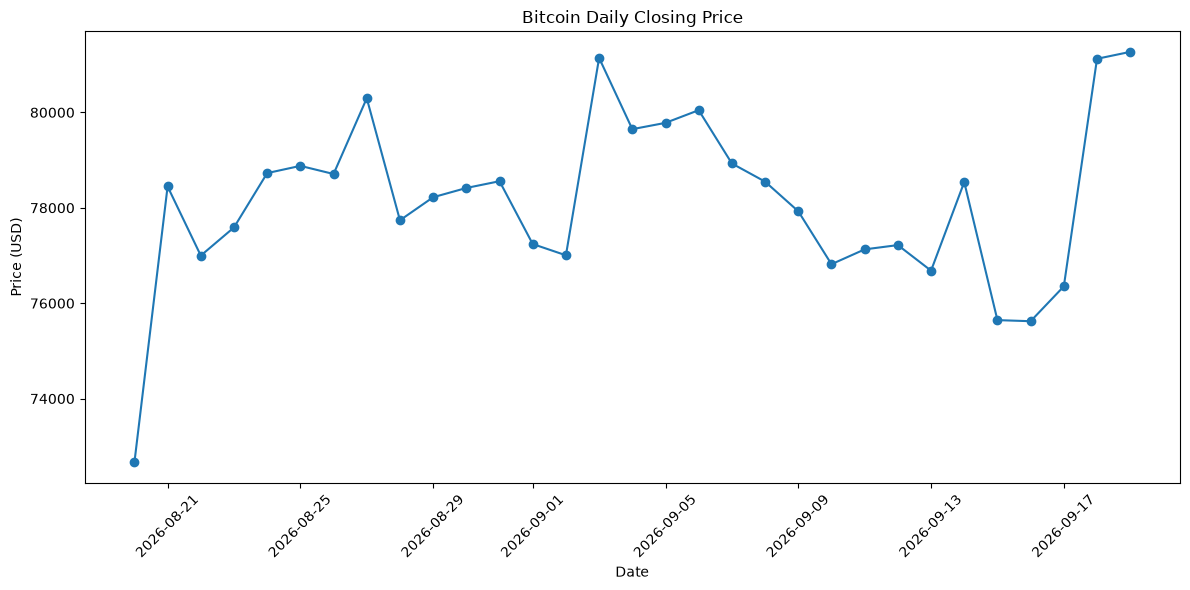

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    daily_market_df["date"],
    daily_market_df["price"],
    marker="o"
)

plt.title("Bitcoin Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 2.17 Bitcoin Drawdown Analysis

Drawdown measures the percentage decline of the Bitcoin price from its previous running peak.

This visualization shows the evolution of drawdown throughout the observation period and highlights periods of increasing downside risk.

The minimum drawdown represents the Maximum Drawdown observed in the dataset.

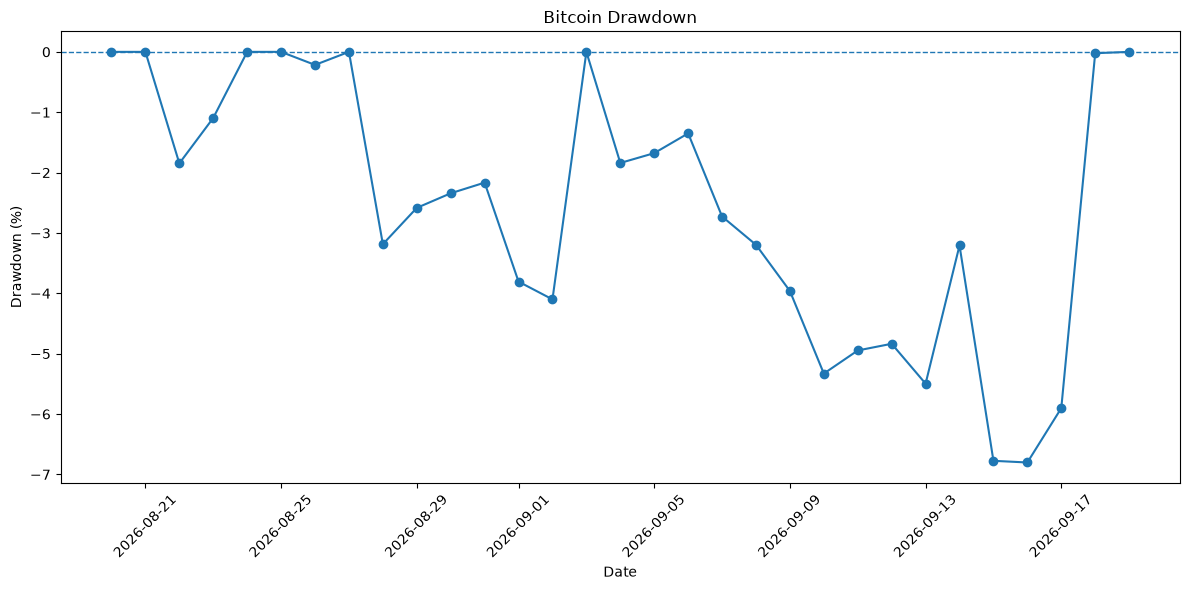

In [64]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_market_df["date"],
    daily_market_df["drawdown"] * 100,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Bitcoin Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 2.18 Rolling Volatility Analysis

Rolling volatility measures how the variability of daily returns changes over time.

A 7-day rolling window is used to identify periods of relatively higher or lower short-term market risk.

This metric complements the overall daily volatility by showing how risk evolves throughout the observation period.

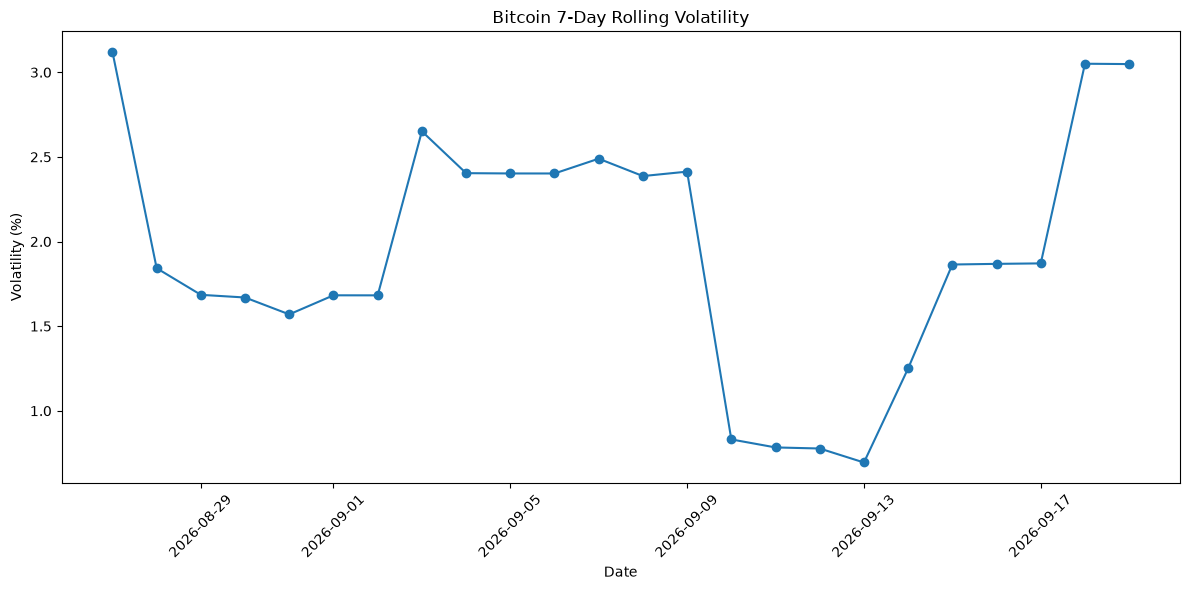

In [65]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_market_df["date"],
    daily_market_df["rolling_volatility_7d"] * 100,
    marker="o"
)

plt.title("Bitcoin 7-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 2.19 Daily Return Analysis

Daily returns measure the percentage change in Bitcoin's closing price from one day to the next.

This visualization shows the distribution of positive and negative daily price movements throughout the observation period.

Daily returns are the basis for several financial risk metrics, including volatility and drawdown analysis.

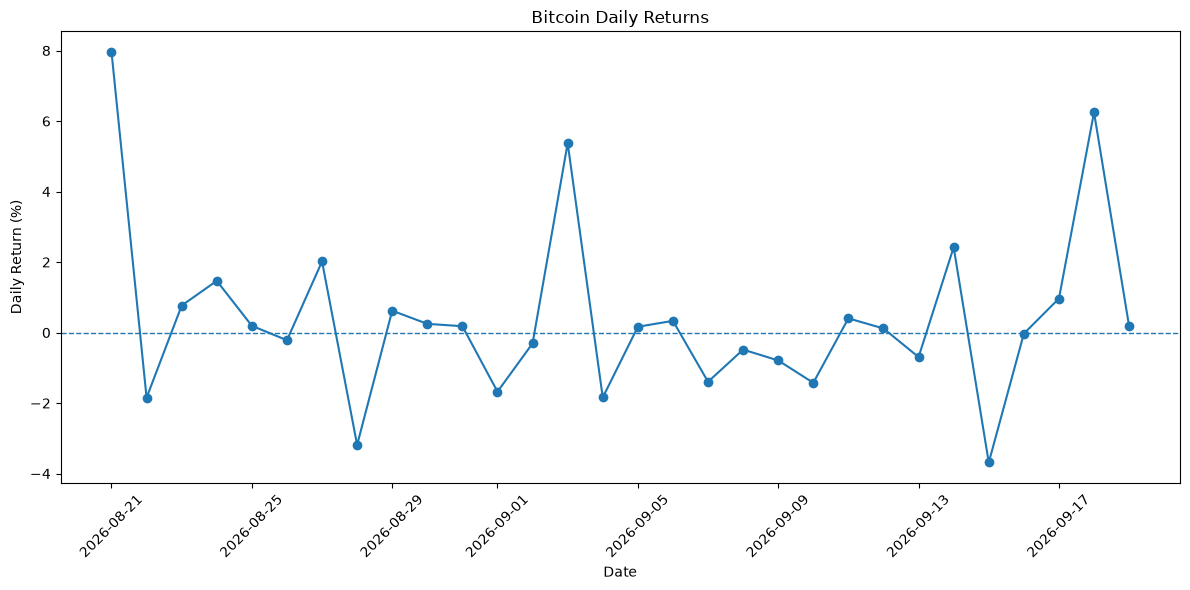

In [66]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_market_df["date"],
    daily_market_df["daily_return"] * 100,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Bitcoin Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()